# Experiment 001 — YOLOv11n Baseline · PCB Defect Detection · 200 Epochs · Run 1

**Pipeline:** `git clone` raw dataset → VOC XML → YOLO txt conversion → stratified 70/20/10 split → train → evaluate → log everything to WandB.

| Property | Value |
|---|---|
| Model | YOLOv11n (nano, ImageNet pretrained) |
| Dataset | PKU-PCB (Ironbrotherstyle/PCB-DATASET) — 693 annotated images |
| Image Size (training) | 640×640 (letterboxed from 3034×1586) |
| Epochs | 200 (early stop patience=50) |
| Batch | 16 · Seed: 42 |
| Classes | missing_hole, mouse_bite, open_circuit, short, spur, spurious_copper |
| Tracking | Weights & Biases |

## 0. Hardware Check

In [1]:
import torch
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM(GB) : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f}")
    print(f"CUDA ver : {torch.version.cuda}")
    print(f"cuDNN ver: {torch.backends.cudnn.version()}")



PyTorch  : 2.5.1+cu124
CUDA     : True
GPU      : NVIDIA GeForce RTX 3090
VRAM(GB) : 25.29
CUDA ver : 12.4
cuDNN ver: 90100


## 1. Install / Upgrade Packages

In [2]:
import subprocess, sys

# ultralytics>=8.3.0 required for YOLO11 (C3k2 block)
for pkg, spec in [("ultralytics", "ultralytics>=8.3.0"), ("wandb", "wandb")]:
    try:
        mod = __import__(pkg)
        ver = tuple(int(x) for x in mod.__version__.split(".")[:2])
        if pkg == "ultralytics" and ver < (8, 3):
            raise ImportError("too old")
        print(f"{pkg} {mod.__version__} OK")
    except Exception:
        print(f"Installing {spec} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", spec, "-q"], check=True)
        print(f"{pkg} installed.")

import ultralytics, wandb
print(f"\nultralytics : {ultralytics.__version__}")
print(f"wandb       : {wandb.__version__}")

ultralytics 8.4.41 OK
wandb 0.26.1 OK

ultralytics : 8.4.41
wandb       : 0.26.1


## 2. WandB Login

In [4]:
import os, wandb

WANDB_API_KEY = "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"
os.environ["WANDB_API_KEY"] = WANDB_API_KEY
wandb.login(key=WANDB_API_KEY, relogin=True)
print("WandB login OK.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/vector/.netrc
wandb: Currently logged in as: abdulllah01 (abdulllah01-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB login OK.


## 3. Clone Raw Dataset

Clones `Ironbrotherstyle/PCB-DATASET` once; skips if already present.

In [6]:
import subprocess
from pathlib import Path

# Resolve project root (works whether jupyter is launched from project root or experiments/)
_cwd = Path(os.getcwd())
PROJECT_ROOT = _cwd.parent if _cwd.name == "experiments" else _cwd
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

DATASET_REPO_URL = "https://github.com/Ironbrotherstyle/PCB-DATASET"
DATASET_RAW_DIR  = PROJECT_ROOT / "PCB-DATASET"

if not (DATASET_RAW_DIR / ".git").exists():
    print("Cloning dataset (this may take a minute for large image files)...")
    result = subprocess.run(
        ["git", "clone", DATASET_REPO_URL, str(DATASET_RAW_DIR)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{result.stderr}")
    print("Clone complete.")
else:
    print(f"Dataset already present at: {DATASET_RAW_DIR}")

# Verify expected directories exist
for d in ["Annotations", "images"]:
    assert (DATASET_RAW_DIR / d).exists(), f"Expected dir missing: {DATASET_RAW_DIR/d}"
print("Dataset structure verified.")

PROJECT_ROOT: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection
Dataset already present at: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/PCB-DATASET
Dataset structure verified.


## 4. Imports, Seeds & Configuration

In [7]:
import os, sys, random, shutil, platform, datetime, json, xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
import wandb
import ultralytics
from ultralytics import YOLO

print("All imports OK.")

All imports OK.


In [8]:
SEED = 42

def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"Seed={SEED} set. cuDNN deterministic=True, benchmark=False.")

Seed=42 set. cuDNN deterministic=True, benchmark=False.


In [9]:
# ── Experiment identifiers ──────────────────────────────────────────────────
EXP_NAME  = "exp_001_yolov11n_baseline_200ep"
RUN_ID    = "run1"
WANDB_RUN = f"{EXP_NAME}_{RUN_ID}"

# ── Model ───────────────────────────────────────────────────────────────────
MODEL_ARCH = "yolo11n.pt"

# ── Training hyperparameters (explicit for full reproducibility) ─────────────
EPOCHS      = 200
BATCH_SIZE  = 16
IMG_SIZE    = 640
DEVICE      = 0      # GPU 0; set 'cpu' if no GPU
PATIENCE    = 50
SAVE_PERIOD = 50

OPTIMIZER      = "auto"
LR0            = 0.01
LRF            = 0.01
MOMENTUM       = 0.937
WEIGHT_DECAY   = 0.0005
WARMUP_EPOCHS  = 3.0
WARMUP_MOM     = 0.8
WARMUP_BIAS_LR = 0.1
BOX_GAIN = 7.5
CLS_GAIN = 0.5
DFL_GAIN = 1.5

AUG = dict(
    hsv_h=0.015, hsv_s=0.7,  hsv_v=0.4,
    degrees=0.0, translate=0.1, scale=0.5,
    shear=0.0,   perspective=0.0,
    flipud=0.0,  fliplr=0.5,
    mosaic=1.0,  mixup=0.0,  copy_paste=0.0,
)

# ── Dataset & paths ──────────────────────────────────────────────────────────
CLASS_NAMES = ['missing_hole', 'mouse_bite', 'open_circuit',
               'short', 'spur', 'spurious_copper']
NUM_CLASSES = 6

CLASS_MAP = {n: i for i, n in enumerate(CLASS_NAMES)}

# Annotation folder names → class index (folder names are Title_case)
FOLDER_CLASS_MAP = {
    'Missing_hole': 0, 'Mouse_bite': 1, 'Open_circuit': 2,
    'Short': 3,        'Spur': 4,       'Spurious_copper': 5,
}

YOLO_DATASET_DIR = PROJECT_ROOT / "pcb_yolo_dataset"
RESULTS_DIR      = PROJECT_ROOT / "results"
DATA_YAML_PATH   = PROJECT_ROOT / "data_pcb_github.yaml"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── WandB config dict ────────────────────────────────────────────────────────
CFG = {
    "exp_name": EXP_NAME, "run_id": RUN_ID, "seed": SEED,
    "model_arch": MODEL_ARCH, "pretrained": True,
    "dataset": "PKU-PCB-GitHub", "dataset_source": DATASET_REPO_URL,
    "num_classes": NUM_CLASSES, "class_names": CLASS_NAMES,
    "epochs": EPOCHS, "batch_size": BATCH_SIZE, "img_size": IMG_SIZE,
    "device": str(DEVICE), "patience": PATIENCE, "save_period": SAVE_PERIOD,
    "optimizer": OPTIMIZER, "lr0": LR0, "lrf": LRF,
    "momentum": MOMENTUM, "weight_decay": WEIGHT_DECAY,
    "warmup_epochs": WARMUP_EPOCHS, "warmup_momentum": WARMUP_MOM,
    "warmup_bias_lr": WARMUP_BIAS_LR,
    "box_gain": BOX_GAIN, "cls_gain": CLS_GAIN, "dfl_gain": DFL_GAIN,
    "split_train_pct": 0.70, "split_val_pct": 0.20, "split_test_pct": 0.10,
    "cudnn_deterministic": True, "cudnn_benchmark": False,
    **{f"aug_{k}": v for k, v in AUG.items()},
}

print(f"Experiment : {WANDB_RUN}")
print(f"Results    : {RESULTS_DIR}")
print(f"YOLO data  : {YOLO_DATASET_DIR}")

Experiment : exp_001_yolov11n_baseline_200ep_run1
Results    : /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results
YOLO data  : /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/pcb_yolo_dataset


## 5. Initialise WandB Run

Must be called before training so ultralytics auto-logs into this run.

In [10]:
run = wandb.init(
    project="pcb-defect-detection",
    name=WANDB_RUN,
    tags=["baseline", "yolov11n", "pcb", "github-dataset", "run1"],
    notes=(
        "Baseline: YOLOv11n on PKU-PCB (Ironbrotherstyle/PCB-DATASET). "
        "Raw VOC XML converted to YOLO in-notebook. "
        "Stratified 70/20/10 split, seed=42. Local Jupyter run."
    ),
    config=CFG,
    save_code=True,
)
print(f"Run name: {run.name}")
print(f"Run URL : {run.url}")

Run name: exp_001_yolov11n_baseline_200ep_run1
Run URL : https://wandb.ai/abdulllah01-fast-nuces/pcb-defect-detection/runs/hit52s7m


## 6. Log System & Environment Info

In [11]:
sys_info = {
    "python_version"     : platform.python_version(),
    "platform"           : platform.platform(),
    "pytorch_version"    : torch.__version__,
    "cuda_version"       : torch.version.cuda or "N/A",
    "cudnn_version"      : str(torch.backends.cudnn.version()) if torch.cuda.is_available() else "N/A",
    "ultralytics_version": ultralytics.__version__,
    "wandb_version"      : wandb.__version__,
    "numpy_version"      : np.__version__,
    "pandas_version"     : pd.__version__,
    "gpu_name"           : torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "gpu_memory_gb"      : round(torch.cuda.get_device_properties(0).total_memory/1e9, 2)
                           if torch.cuda.is_available() else 0,
    "num_gpus"           : torch.cuda.device_count(),
    "experiment_start"   : datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}
wandb.config.update({"system": sys_info})
wandb.log({"system/environment": wandb.Table(
    columns=["Property", "Value"],
    data=[[k, str(v)] for k, v in sys_info.items()]
)})
for k, v in sys_info.items():
    print(f"  {k:<25} = {v}")

  python_version            = 3.11.9
  platform                  = Linux-6.14.0-37-generic-x86_64-with-glibc2.41
  pytorch_version           = 2.5.1+cu124
  cuda_version              = 12.4
  cudnn_version             = 90100
  ultralytics_version       = 8.4.41
  wandb_version             = 0.26.1
  numpy_version             = 1.26.4
  pandas_version            = 3.0.1
  gpu_name                  = NVIDIA GeForce RTX 3090
  gpu_memory_gb             = 25.29
  num_gpus                  = 1
  experiment_start          = 2026-04-26 19:57:51


## 7. Dataset Preparation

### 7.1 VOC XML → YOLO Format Conversion

In [12]:
def voc_to_yolo(xml_path: Path):
    """
    Parse a Pascal VOC XML, return (img_w, img_h, boxes).
    boxes: list of (cls_id, cx_norm, cy_norm, bw_norm, bh_norm)
    Coordinates are clamped to [0,1].
    """
    root = ET.parse(xml_path).getroot()
    size = root.find('size')
    img_w = int(size.find('width').text)
    img_h = int(size.find('height').text)
    boxes = []
    for obj in root.findall('object'):
        name   = obj.find('name').text.strip()
        cls_id = CLASS_MAP.get(name)
        if cls_id is None:
            print(f"  WARNING: unknown class '{name}' in {xml_path.name} — skipped.")
            continue
        b    = obj.find('bndbox')
        xmin = max(0.0,    float(b.find('xmin').text))
        ymin = max(0.0,    float(b.find('ymin').text))
        xmax = min(img_w,  float(b.find('xmax').text))
        ymax = min(img_h,  float(b.find('ymax').text))
        if xmax <= xmin or ymax <= ymin:
            print(f"  WARNING: degenerate box in {xml_path.name} — skipped.")
            continue
        cx = (xmin + xmax) / 2.0 / img_w
        cy = (ymin + ymax) / 2.0 / img_h
        bw = (xmax - xmin) / img_w
        bh = (ymax - ymin) / img_h
        boxes.append((cls_id, cx, cy, bw, bh))
    return img_w, img_h, boxes

# ── Collect all annotated samples ────────────────────────────────────────────
ANN_DIR = DATASET_RAW_DIR / 'Annotations'
IMG_DIR = DATASET_RAW_DIR / 'images'

all_samples = []  # list of (xml_path, img_path, cls_folder_name)
for cls_folder in sorted(ANN_DIR.iterdir()):
    if not cls_folder.is_dir():
        continue
    for xml_path in sorted(cls_folder.glob('*.xml')):
        img_path = IMG_DIR / cls_folder.name / (xml_path.stem + '.jpg')
        if img_path.exists():
            all_samples.append((xml_path, img_path, cls_folder.name))
        else:
            print(f"WARNING: image not found for {xml_path}")

print(f"Total annotated image-XML pairs found: {len(all_samples)}")
for cls in sorted(set(s[2] for s in all_samples)):
    n = sum(1 for s in all_samples if s[2] == cls)
    print(f"  {cls:<22}: {n} images")

Total annotated image-XML pairs found: 693
  Missing_hole          : 115 images
  Mouse_bite            : 115 images
  Open_circuit          : 116 images
  Short                 : 116 images
  Spur                  : 115 images
  Spurious_copper       : 116 images


### 7.2 Stratified 70 / 20 / 10 Split (seed=42)

In [13]:
rng = np.random.default_rng(SEED)

train_samples, val_samples, test_samples = [], [], []

class_groups = defaultdict(list)
for sample in all_samples:
    class_groups[sample[2]].append(sample)

split_log = []
for cls_name in sorted(class_groups.keys()):
    samples = class_groups[cls_name]
    n       = len(samples)
    idx     = rng.permutation(n)

    n_test  = max(1, round(n * 0.10))
    n_val   = max(1, round(n * 0.20))
    n_train = n - n_val - n_test

    train_samples.extend([samples[i] for i in idx[:n_train]])
    val_samples.extend(  [samples[i] for i in idx[n_train : n_train + n_val]])
    test_samples.extend( [samples[i] for i in idx[n_train + n_val:]])

    split_log.append({"Class": cls_name, "Train": n_train, "Val": n_val,
                      "Test": n_test, "Total": n})

split_df = pd.DataFrame(split_log)
split_df.loc[len(split_df)] = ["TOTAL",
    len(train_samples), len(val_samples), len(test_samples),
    len(all_samples)]

print(split_df.to_string(index=False))
print(f"\nFinal split — Train: {len(train_samples)} | "
      f"Val: {len(val_samples)} | Test: {len(test_samples)}")

# Log to wandb
wandb.log({"dataset/split_by_class": wandb.Table(dataframe=split_df)})
wandb.config.update({
    "dataset/n_train": len(train_samples),
    "dataset/n_val"  : len(val_samples),
    "dataset/n_test" : len(test_samples),
    "dataset/n_total": len(all_samples),
})

# Save split manifest for reproducibility
manifest = {
    "seed": SEED,
    "train": [str(s[1].name) for s in train_samples],
    "val"  : [str(s[1].name) for s in val_samples],
    "test" : [str(s[1].name) for s in test_samples],
}
manifest_path = RESULTS_DIR / f"{EXP_NAME}_split_manifest.json"
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)
print(f"Split manifest saved: {manifest_path}")

          Class  Train  Val  Test  Total
   Missing_hole     80   23    12    115
     Mouse_bite     80   23    12    115
   Open_circuit     81   23    12    116
          Short     81   23    12    116
           Spur     80   23    12    115
Spurious_copper     81   23    12    116
          TOTAL    483  138    72    693

Final split — Train: 483 | Val: 138 | Test: 72
Split manifest saved: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_001_yolov11n_baseline_200ep_split_manifest.json


### 7.3 Build YOLO Dataset on Disk

In [14]:
def build_yolo_split(samples, split_name: str, force: bool = False):
    """
    Copy images and write YOLO .txt labels for one split.
    Skips if already built (unless force=True).
    Returns annotation stats: Counter of cls_id.
    """
    img_out = YOLO_DATASET_DIR / split_name / "images"
    lbl_out = YOLO_DATASET_DIR / split_name / "labels"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    counts = Counter()
    for xml_path, img_path, _ in samples:
        dst_img = img_out / img_path.name
        if force or not dst_img.exists():
            shutil.copy2(img_path, dst_img)

        img_w, img_h, boxes = voc_to_yolo(xml_path)
        lbl_path = lbl_out / (img_path.stem + ".txt")
        with open(lbl_path, 'w') as f:
            for cls_id, cx, cy, bw, bh in boxes:
                f.write(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
                counts[cls_id] += 1
    return counts

print("Building YOLO dataset (copying images + writing labels)...")
print("  This copies ~693 large images — may take a minute.\n")

train_counts = build_yolo_split(train_samples, "train")
val_counts   = build_yolo_split(val_samples,   "val")
test_counts  = build_yolo_split(test_samples,  "test")

print(f"  train: {len(train_samples)} images, {sum(train_counts.values())} annotations")
print(f"  val  : {len(val_samples)}   images, {sum(val_counts.values())}   annotations")
print(f"  test : {len(test_samples)}  images, {sum(test_counts.values())}  annotations")
print("\nYOLO dataset built.")

Building YOLO dataset (copying images + writing labels)...
  This copies ~693 large images — may take a minute.

  train: 483 images, 2058 annotations
  val  : 138   images, 589   annotations
  test : 72  images, 306  annotations

YOLO dataset built.


### 7.4 Write data.yaml

In [15]:
yaml_content = (
    f"train: {(YOLO_DATASET_DIR / 'train' / 'images').as_posix()}\n"
    f"val:   {(YOLO_DATASET_DIR / 'val'   / 'images').as_posix()}\n"
    f"test:  {(YOLO_DATASET_DIR / 'test'  / 'images').as_posix()}\n"
    f"\nnc: {NUM_CLASSES}\n"
    f"names: {CLASS_NAMES}\n"
)
DATA_YAML_PATH.write_text(yaml_content)
print(f"data.yaml written to: {DATA_YAML_PATH}")
print(yaml_content)

data.yaml written to: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/data_pcb_github.yaml
train: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/pcb_yolo_dataset/train/images
val:   /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/pcb_yolo_dataset/val/images
test:  /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/pcb_yolo_dataset/test/images

nc: 6
names: ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']



## 8. Dataset EDA

### 8.1 Annotation Distribution

          Class  Train  Val  Test  Total
   missing_hole    351   96    50    497
     mouse_bite    338  101    53    492
   open_circuit    337   97    48    482
          short    333  106    52    491
           spur    341   93    54    488
spurious_copper    358   96    49    503

Total annotations: 2953


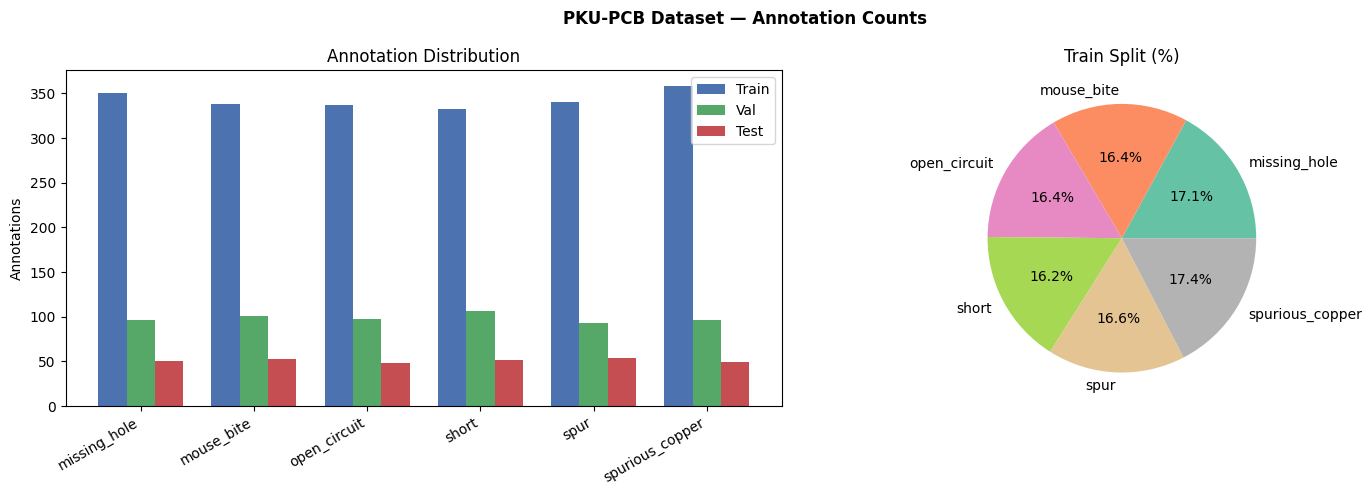

In [16]:
dist_df = pd.DataFrame({
    "Class" : CLASS_NAMES,
    "Train" : [train_counts[i] for i in range(NUM_CLASSES)],
    "Val"   : [val_counts[i]   for i in range(NUM_CLASSES)],
    "Test"  : [test_counts[i]  for i in range(NUM_CLASSES)],
})
dist_df["Total"] = dist_df[["Train","Val","Test"]].sum(axis=1)
print(dist_df.to_string(index=False))
print(f"\nTotal annotations: {dist_df['Total'].sum()}")

wandb.log({"dataset/annotation_distribution": wandb.Table(dataframe=dist_df)})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
x, w = np.arange(NUM_CLASSES), 0.25
ax.bar(x-w,  dist_df["Train"], w, label="Train", color="#4C72B0")
ax.bar(x,    dist_df["Val"],   w, label="Val",   color="#55A868")
ax.bar(x+w,  dist_df["Test"],  w, label="Test",  color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_ylabel("Annotations"); ax.set_title("Annotation Distribution"); ax.legend()
axes[1].pie(dist_df["Train"], labels=CLASS_NAMES, autopct="%1.1f%%",
            colors=plt.cm.Set2(np.linspace(0,1,NUM_CLASSES)))
axes[1].set_title("Train Split (%)")
plt.suptitle("PKU-PCB Dataset — Annotation Counts", fontsize=12, fontweight="bold")
plt.tight_layout()
dist_plot = str(RESULTS_DIR / f"{EXP_NAME}_annotation_distribution.png")
plt.savefig(dist_plot, dpi=150)
wandb.log({"dataset/annotation_dist_plot": wandb.Image(dist_plot)})
plt.show()

### 8.2 Image Dimension Statistics

In [17]:
from PIL import Image as PILImage

widths, heights = [], []
sample_pool = [s[1] for s in train_samples[:50]]  # first 50 for speed
for p in sample_pool:
    try:
        with PILImage.open(p) as im:
            widths.append(im.width); heights.append(im.height)
    except Exception: pass

dim_stats = {
    "width_mean":  round(float(np.mean(widths)),  1),
    "width_std":   round(float(np.std(widths)),   1),
    "height_mean": round(float(np.mean(heights)), 1),
    "height_std":  round(float(np.std(heights)),  1),
    "width_min":   int(np.min(widths)),  "width_max":  int(np.max(widths)),
    "height_min":  int(np.min(heights)), "height_max": int(np.max(heights)),
    "note":        f"Training uses letterbox resize to {IMG_SIZE}x{IMG_SIZE}",
}
for k, v in dim_stats.items():
    print(f"  {k:<18} = {v}")
wandb.config.update({"dataset/img_dim_stats": dim_stats})
wandb.log({"dataset/img_dim_stats": wandb.Table(
    columns=["Stat","Value"], data=[[k,str(v)] for k,v in dim_stats.items()]
)})

  width_mean         = 2783.6
  width_std          = 269.3
  height_mean        = 2182.8
  height_std         = 288.2
  width_min          = 2240
  width_max          = 3056
  height_min         = 1586
  height_max         = 2530
  note               = Training uses letterbox resize to 640x640


### 8.3 Sample Training Images with Ground-Truth Boxes

wandb: WARNING Artifact "source-pcb-defect-detection-_home_vector_Documents_abdullah_workspace_PCB_Defect_Dectection_experiments_run1.ipynb" already exists with the same content. No new version will be created.


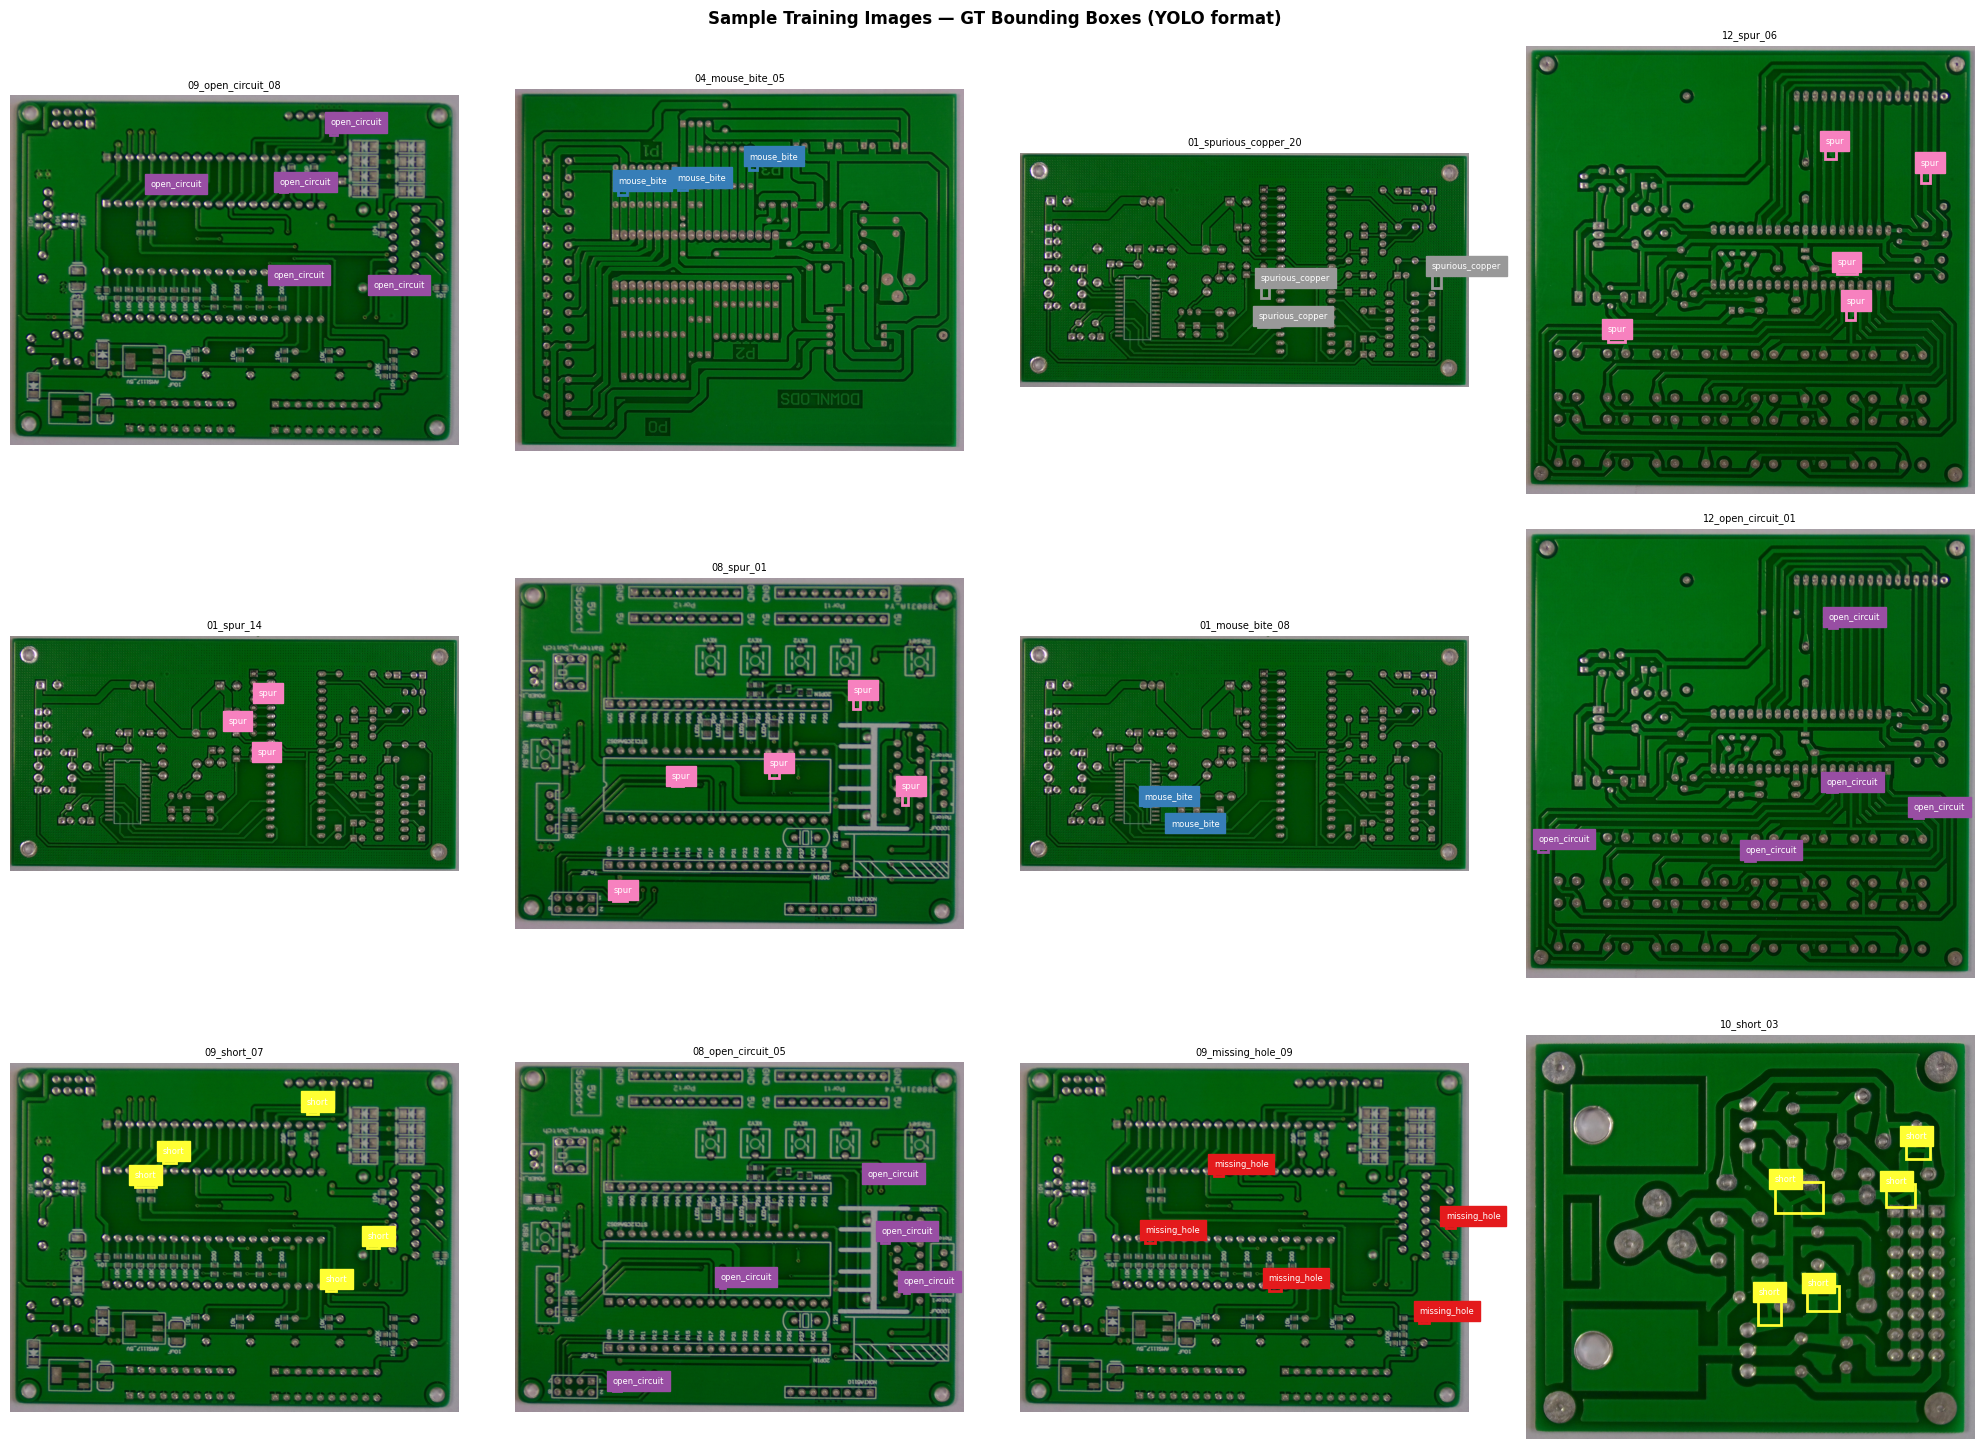

Sample images logged.


In [18]:
COLORS = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))

def draw_yolo_boxes(img_path: Path, lbl_path: Path, ax: plt.Axes):
    img = mpimg.imread(str(img_path))
    h, w = img.shape[:2]
    ax.imshow(img)
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            p = line.strip().split()
            if not p: continue
            c, cx, cy, bw, bh = int(p[0]), *map(float, p[1:5])
            x1 = (cx - bw/2)*w; y1 = (cy - bh/2)*h
            ax.add_patch(plt.Rectangle((x1,y1), bw*w, bh*h,
                lw=2, edgecolor=COLORS[c], facecolor='none'))
            ax.text(x1, max(y1-3,0), CLASS_NAMES[c], fontsize=6,
                    color='white', backgroundcolor=COLORS[c])
    ax.axis('off')
    ax.set_title(img_path.stem[:25], fontsize=7)

random.seed(SEED)
sample_paths = random.sample(
    list((YOLO_DATASET_DIR/'train'/'images').glob('*.jpg')),
    min(12, len(train_samples))
)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
for ax, img_path in zip(axes.flat, sample_paths):
    lbl_path = YOLO_DATASET_DIR/'train'/'labels'/(img_path.stem+'.txt')
    draw_yolo_boxes(img_path, lbl_path, ax)
plt.suptitle("Sample Training Images — GT Bounding Boxes (YOLO format)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
samples_plot = str(RESULTS_DIR / f"{EXP_NAME}_sample_images.png")
plt.savefig(samples_plot, dpi=100)
wandb.log({"dataset/sample_images": wandb.Image(samples_plot,
           caption="Sample training images with GT boxes")})
plt.show()
print("Sample images logged.")

## 9. Download YOLOv11n Weights

In [19]:
import urllib.request

MODEL_LOCAL_PATH = Path(MODEL_ARCH)  # 'yolo11n.pt'

if not MODEL_LOCAL_PATH.exists():
    try:
        from ultralytics.utils.downloads import attempt_download_asset
        downloaded = Path(attempt_download_asset(MODEL_ARCH))
        if downloaded.exists():
            MODEL_LOCAL_PATH = downloaded
            print(f"Downloaded via ultralytics: {MODEL_LOCAL_PATH}")
        else:
            raise FileNotFoundError("attempt_download_asset returned missing path")
    except Exception as e:
        print(f"ultralytics download failed ({e}), falling back...")
        url = "https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt"
        urllib.request.urlretrieve(url, str(MODEL_LOCAL_PATH))
        print(f"Downloaded from GitHub: {MODEL_LOCAL_PATH.resolve()}")
else:
    print(f"Weights cached: {MODEL_LOCAL_PATH.resolve()}")

assert MODEL_LOCAL_PATH.exists()
size_mb = MODEL_LOCAL_PATH.stat().st_size / 1e6
print(f"Weight file ready — {size_mb:.1f} MB")
wandb.log({"model/weight_size_mb": round(size_mb, 2)})

Weights cached: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/yolo11n.pt
Weight file ready — 5.6 MB


## 10. Model Training

All hyperparameters are explicit. Ultralytics detects the active WandB run and logs per-epoch metrics automatically.

In [20]:
seed_everything(SEED)  # re-seed immediately before training

print(f"{'='*65}")
print(f"  Starting YOLOv11n Training — {WANDB_RUN}")
print(f"  Epochs:{EPOCHS} | Batch:{BATCH_SIZE} | ImgSz:{IMG_SIZE} | Seed:{SEED}")
print(f"  Start: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'='*65}\n")

model = YOLO(str(MODEL_LOCAL_PATH))

train_results = model.train(
    data=str(DATA_YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=str(RESULTS_DIR),
    name=EXP_NAME,
    exist_ok=True,
    # early stopping
    patience=PATIENCE,
    # checkpointing
    save=True,
    save_period=SAVE_PERIOD,
    # reproducibility
    seed=SEED,
    deterministic=True,
    # optimizer
    optimizer=OPTIMIZER,
    lr0=LR0, lrf=LRF,
    momentum=MOMENTUM, weight_decay=WEIGHT_DECAY,
    warmup_epochs=WARMUP_EPOCHS, warmup_momentum=WARMUP_MOM,
    warmup_bias_lr=WARMUP_BIAS_LR,
    # loss
    box=BOX_GAIN, cls=CLS_GAIN, dfl=DFL_GAIN,
    # augmentation (explicit for reproducibility)
    **AUG,
    # output
    plots=True, verbose=True,
)

TRAIN_END_TIME = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"\nTraining completed at: {TRAIN_END_TIME}")
wandb.log({"training/end_time": TRAIN_END_TIME})

BEST_MODEL_PATH = RESULTS_DIR / EXP_NAME / "weights" / "best.pt"
LAST_MODEL_PATH = RESULTS_DIR / EXP_NAME / "weights" / "last.pt"
RESULTS_CSV     = RESULTS_DIR / EXP_NAME / "results.csv"
print(f"Best weights: {BEST_MODEL_PATH}")

  Starting YOLOv11n Training — exp_001_yolov11n_baseline_200ep_run1
  Epochs:200 | Batch:16 | ImgSz:640 | Seed:42
  Start: 2026-04-26 19:58:02

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24115MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/data_pcb_github.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=

## 11. Validation Set Evaluation

In [21]:
best_model = YOLO(str(BEST_MODEL_PATH))

val_results = best_model.val(
    data=str(DATA_YAML_PATH),
    split="val",
    imgsz=IMG_SIZE, batch=BATCH_SIZE, device=DEVICE,
    project=str(RESULTS_DIR), name=f"{EXP_NAME}_val_eval",
    exist_ok=True, plots=True,
)
print("Validation evaluation complete.")

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24115MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6079.9±1161.2 MB/s, size: 1445.3 KB)
val: Scanning /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/pcb_yolo_dataset/val/labels.cache... 138 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 138/138 96.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 6.6it/s 1.4s0.2ss
                   all        138        589      0.944      0.861      0.917      0.466
          missing_hole         23         96      0.979       0.99      0.976      0.585
            mouse_bite         23        101      0.929      0.772      0.867       0.42
          open_circuit         23         97      0.908      0.918      0.972      0.453
                 short         23        106      0.96

In [22]:
val_P   = float(val_results.box.mp)
val_R   = float(val_results.box.mr)
val_m50 = float(val_results.box.map50)
val_m   = float(val_results.box.map)
val_F1  = 2*val_P*val_R / (val_P+val_R+1e-8)

val_overall = {
    "val/precision": round(val_P,4), "val/recall":   round(val_R,4),
    "val/f1":        round(val_F1,4), "val/mAP50":    round(val_m50,4),
    "val/mAP50-95":  round(val_m,4),
}
wandb.log(val_overall)
wandb.run.summary.update(val_overall)

print("\n" + "="*50 + "\n  VALIDATION — Overall Metrics\n" + "="*50)
print(pd.DataFrame({"Metric":["Precision","Recall","F1","mAP@50","mAP@50-95"],
                    "Value":[val_P,val_R,val_F1,val_m50,val_m]})
      .assign(Value=lambda d: d.Value.map("{:.4f}".format))
      .to_string(index=False))


  VALIDATION — Overall Metrics
   Metric  Value
Precision 0.9444
   Recall 0.8610
       F1 0.9007
   mAP@50 0.9170
mAP@50-95 0.4665


In [23]:
val_pc_P   = val_results.box.p
val_pc_R   = val_results.box.r
val_pc_a50 = val_results.box.ap50
val_pc_a   = val_results.box.ap
val_pc_F1  = 2*val_pc_P*val_pc_R / (val_pc_P+val_pc_R+1e-8)

val_pc_df = pd.DataFrame({
    "Class"    : CLASS_NAMES,
    "Precision": [round(float(v),4) for v in val_pc_P],
    "Recall"   : [round(float(v),4) for v in val_pc_R],
    "F1"       : [round(float(v),4) for v in val_pc_F1],
    "AP@50"    : [round(float(v),4) for v in val_pc_a50],
    "AP@50-95" : [round(float(v),4) for v in val_pc_a],
})
print("\n" + "="*50 + "\n  VALIDATION — Per-Class\n" + "="*50)
print(val_pc_df.to_string(index=False))
wandb.log({"val/per_class_metrics": wandb.Table(dataframe=val_pc_df)})
for _, row in val_pc_df.iterrows():
    c = row["Class"]
    wandb.log({f"val_pc/{c}/precision":row["Precision"], f"val_pc/{c}/recall":row["Recall"],
               f"val_pc/{c}/f1":row["F1"], f"val_pc/{c}/ap50":row["AP@50"],
               f"val_pc/{c}/ap50_95":row["AP@50-95"]})
print("Per-class val metrics logged.")


  VALIDATION — Per-Class
          Class  Precision  Recall     F1  AP@50  AP@50-95
   missing_hole     0.9790  0.9896 0.9843 0.9762    0.5852
     mouse_bite     0.9290  0.7723 0.8434 0.8672    0.4204
   open_circuit     0.9081  0.9175 0.9128 0.9722    0.4533
          short     0.9688  0.9434 0.9559 0.9836    0.4997
           spur     0.9410  0.7097 0.8091 0.7860    0.3968
spurious_copper     0.9403  0.8333 0.8836 0.9170    0.4435
Per-class val metrics logged.


## 12. Test Set Evaluation

In [24]:
test_results = best_model.val(
    data=str(DATA_YAML_PATH),
    split="test",
    imgsz=IMG_SIZE, batch=BATCH_SIZE, device=DEVICE,
    project=str(RESULTS_DIR), name=f"{EXP_NAME}_test_eval",
    exist_ok=True, plots=True,
)
print("Test evaluation complete.")

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24115MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6509.0±2117.1 MB/s, size: 1354.0 KB)
val: Scanning /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/pcb_yolo_dataset/test/labels... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 2.1Kit/s 0.0s
val: New cache created: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/pcb_yolo_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.4it/s 1.1s0.3s
                   all         72        306      0.956      0.876      0.924      0.472
          missing_hole         12         50      0.991          1      0.995      0.555
            mouse_bite         12         53      0.886       0.83      0.846      0.482
          open_circuit         12         48      0.931       0.84      0.923      0.401
                 short  

In [25]:
test_P   = float(test_results.box.mp)
test_R   = float(test_results.box.mr)
test_m50 = float(test_results.box.map50)
test_m   = float(test_results.box.map)
test_F1  = 2*test_P*test_R / (test_P+test_R+1e-8)

test_overall = {
    "test/precision": round(test_P,4), "test/recall":   round(test_R,4),
    "test/f1":        round(test_F1,4), "test/mAP50":    round(test_m50,4),
    "test/mAP50-95":  round(test_m,4),
}
wandb.log(test_overall)
wandb.run.summary.update(test_overall)

print("\n" + "="*50 + "\n  TEST — Overall Metrics\n" + "="*50)
print(pd.DataFrame({"Metric":["Precision","Recall","F1","mAP@50","mAP@50-95"],
                    "Value":[test_P,test_R,test_F1,test_m50,test_m]})
      .assign(Value=lambda d: d.Value.map("{:.4f}".format))
      .to_string(index=False))


  TEST — Overall Metrics
   Metric  Value
Precision 0.9558
   Recall 0.8759
       F1 0.9141
   mAP@50 0.9244
mAP@50-95 0.4718


In [26]:
test_pc_P   = test_results.box.p
test_pc_R   = test_results.box.r
test_pc_a50 = test_results.box.ap50
test_pc_a   = test_results.box.ap
test_pc_F1  = 2*test_pc_P*test_pc_R / (test_pc_P+test_pc_R+1e-8)

test_pc_df = pd.DataFrame({
    "Class"    : CLASS_NAMES,
    "Precision": [round(float(v),4) for v in test_pc_P],
    "Recall"   : [round(float(v),4) for v in test_pc_R],
    "F1"       : [round(float(v),4) for v in test_pc_F1],
    "AP@50"    : [round(float(v),4) for v in test_pc_a50],
    "AP@50-95" : [round(float(v),4) for v in test_pc_a],
})
print("\n" + "="*50 + "\n  TEST — Per-Class\n" + "="*50)
print(test_pc_df.to_string(index=False))
wandb.log({"test/per_class_metrics": wandb.Table(dataframe=test_pc_df)})
for _, row in test_pc_df.iterrows():
    c = row["Class"]
    wandb.log({f"test_pc/{c}/precision":row["Precision"], f"test_pc/{c}/recall":row["Recall"],
               f"test_pc/{c}/f1":row["F1"], f"test_pc/{c}/ap50":row["AP@50"],
               f"test_pc/{c}/ap50_95":row["AP@50-95"]})


  TEST — Per-Class
          Class  Precision  Recall     F1  AP@50  AP@50-95
   missing_hole     0.9910  1.0000 0.9955 0.9950    0.5553
     mouse_bite     0.8862  0.8302 0.8573 0.8464    0.4823
   open_circuit     0.9307  0.8399 0.8830 0.9231    0.4009
          short     0.9565  0.9231 0.9395 0.9645    0.4984
           spur     0.9954  0.8704 0.9287 0.9251    0.4435
spurious_copper     0.9749  0.7921 0.8740 0.8921    0.4501


In [27]:
compare_df = pd.DataFrame([
    {"Split":"Validation","Precision":val_P, "Recall":val_R, "F1":val_F1,
     "mAP@50":val_m50,  "mAP@50-95":val_m},
    {"Split":"Test",      "Precision":test_P,"Recall":test_R,"F1":test_F1,
     "mAP@50":test_m50, "mAP@50-95":test_m},
])
print("\n" + "="*65)
print("  VAL vs TEST")
print("="*65)
print(compare_df.to_string(index=False, float_format="{:.4f}".format))
wandb.log({"summary/val_vs_test": wandb.Table(dataframe=compare_df)})


  VAL vs TEST
     Split  Precision  Recall     F1  mAP@50  mAP@50-95
Validation     0.9444  0.8610 0.9007  0.9170     0.4665
      Test     0.9558  0.8759 0.9141  0.9244     0.4718


## 13. Training Curves

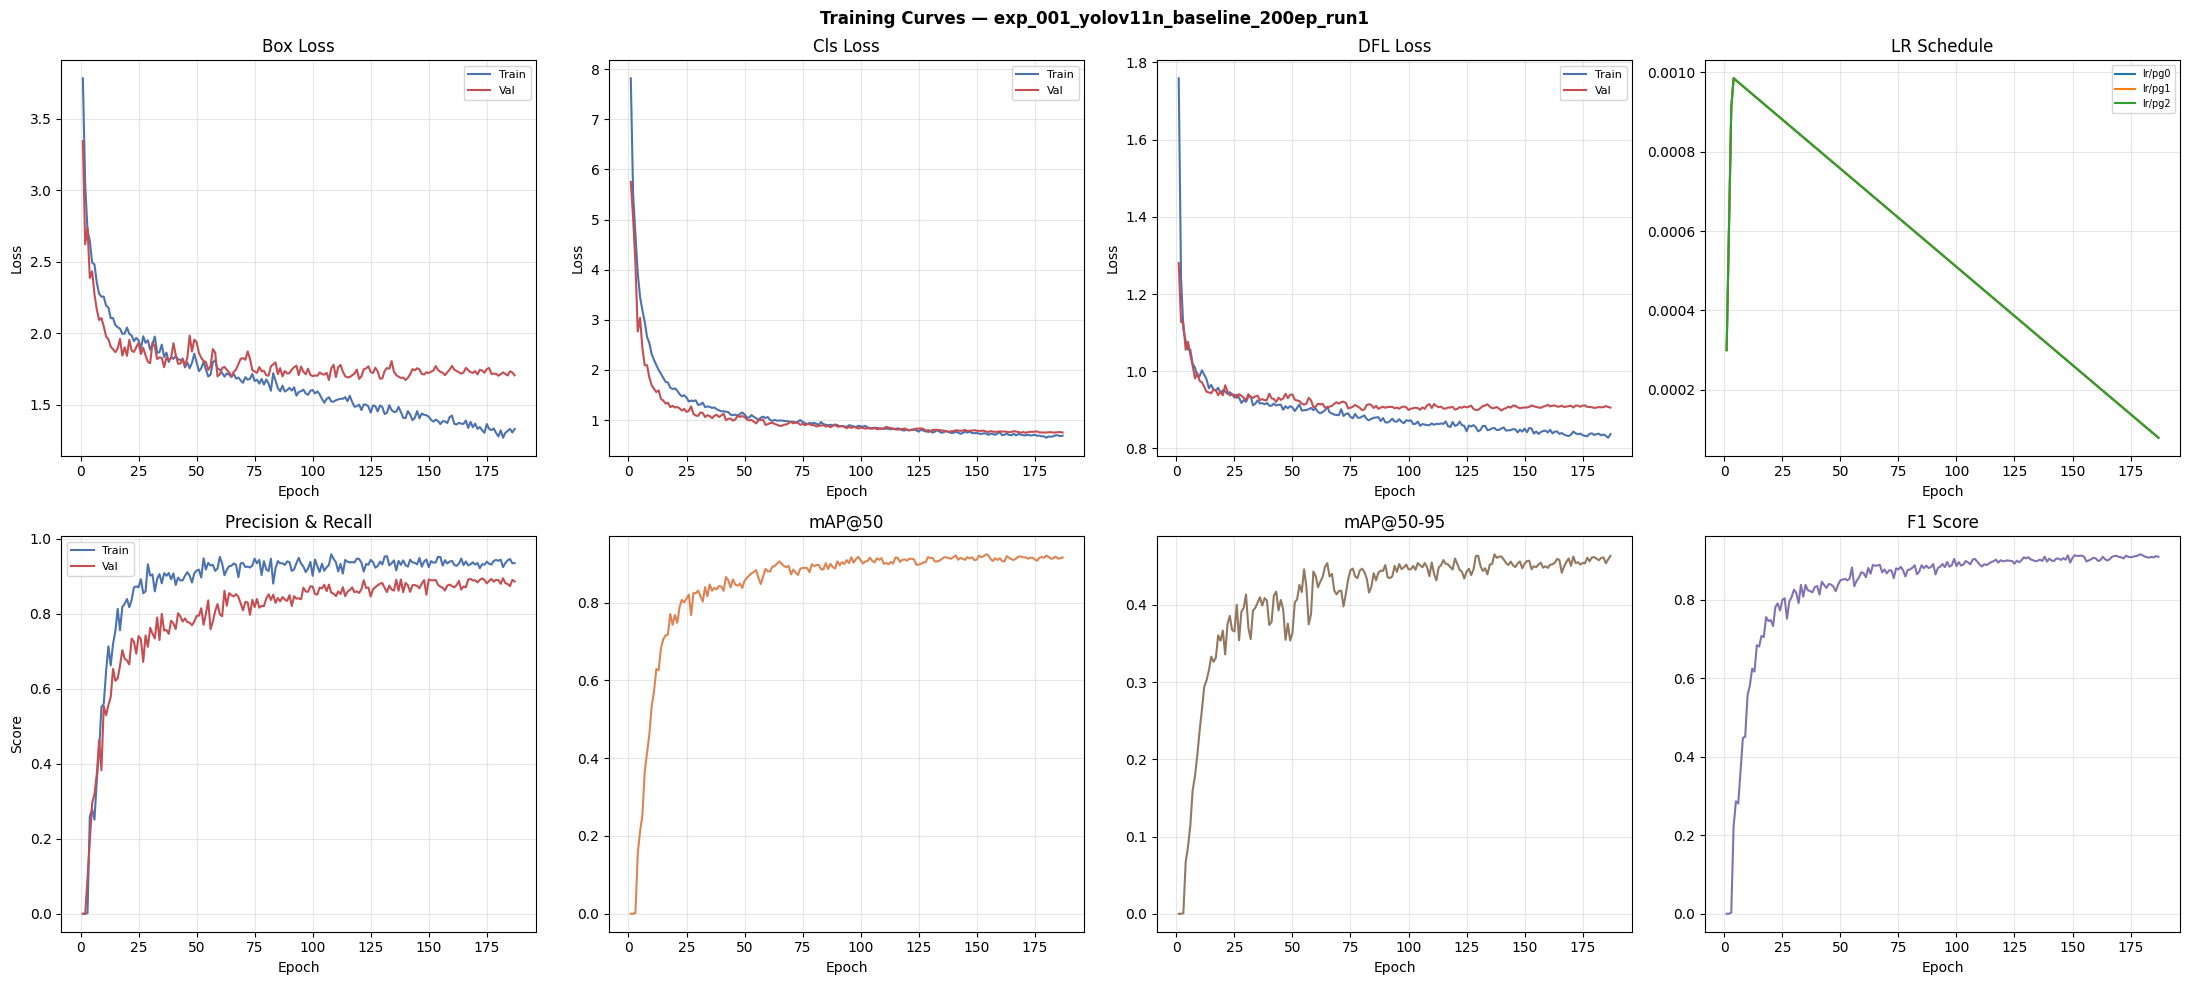

In [28]:
if RESULTS_CSV.exists():
    res_df = pd.read_csv(str(RESULTS_CSV))
    res_df.columns = res_df.columns.str.strip()
    wandb.log({"training/epoch_metrics_table": wandb.Table(dataframe=res_df)})

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    def plot_ax(ax, col_tr, col_val, title, ylabel="Loss"):
        if col_tr and col_tr in res_df.columns:
            ax.plot(res_df["epoch"], res_df[col_tr],  label="Train", color="#4C72B0", lw=1.5)
        if col_val and col_val in res_df.columns:
            ax.plot(res_df["epoch"], res_df[col_val], label="Val",   color="#C44E52", lw=1.5)
        ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plot_ax(axes[0,0], "train/box_loss", "val/box_loss", "Box Loss")
    plot_ax(axes[0,1], "train/cls_loss", "val/cls_loss", "Cls Loss")
    plot_ax(axes[0,2], "train/dfl_loss", "val/dfl_loss", "DFL Loss")

    lr_cols = [c for c in res_df.columns if "lr" in c.lower()]
    for lc in lr_cols:
        axes[0,3].plot(res_df["epoch"], res_df[lc], label=lc, lw=1.5)
    axes[0,3].set_title("LR Schedule"); axes[0,3].legend(fontsize=7)
    axes[0,3].set_xlabel("Epoch"); axes[0,3].grid(alpha=0.3)

    plot_ax(axes[1,0], "metrics/precision(B)", "metrics/recall(B)",
            "Precision & Recall", ylabel="Score")
    if "metrics/mAP50(B)" in res_df.columns:
        axes[1,1].plot(res_df["epoch"], res_df["metrics/mAP50(B)"], color="#DD8452", lw=1.5)
    axes[1,1].set_title("mAP@50"); axes[1,1].grid(alpha=0.3)
    if "metrics/mAP50-95(B)" in res_df.columns:
        axes[1,2].plot(res_df["epoch"], res_df["metrics/mAP50-95(B)"], color="#937860", lw=1.5)
    axes[1,2].set_title("mAP@50-95"); axes[1,2].grid(alpha=0.3)
    if "metrics/precision(B)" in res_df.columns and "metrics/recall(B)" in res_df.columns:
        ep_F1 = 2*res_df["metrics/precision(B)"]*res_df["metrics/recall(B)"] / \
                (res_df["metrics/precision(B)"]+res_df["metrics/recall(B)"]+1e-8)
        axes[1,3].plot(res_df["epoch"], ep_F1, color="#8172B2", lw=1.5)
    axes[1,3].set_title("F1 Score"); axes[1,3].grid(alpha=0.3)
    for ax in axes[1,1:]:
        ax.set_xlabel("Epoch")

    plt.suptitle(f"Training Curves — {WANDB_RUN}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    curves_path = str(RESULTS_DIR / f"{EXP_NAME}_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    wandb.log({"training/curves": wandb.Image(curves_path)})
    plt.show()
else:
    print(f"results.csv not found at {RESULTS_CSV}")

## 14. Log YOLO Diagnostic Plots

In [29]:
def log_yolo_plots(run_dir: Path, prefix: str):
    plots = [
        ("confusion_matrix.png",            f"{prefix}/confusion_matrix"),
        ("confusion_matrix_normalized.png", f"{prefix}/confusion_matrix_norm"),
        ("F1_curve.png",                    f"{prefix}/F1_curve"),
        ("P_curve.png",                     f"{prefix}/P_curve"),
        ("R_curve.png",                     f"{prefix}/R_curve"),
        ("PR_curve.png",                    f"{prefix}/PR_curve"),
        ("results.png",                     f"{prefix}/results_grid"),
        ("labels.jpg",                      f"{prefix}/label_dist"),
        ("labels_correlogram.jpg",          f"{prefix}/label_correlogram"),
    ]
    logged = []
    for fname, key in plots:
        p = run_dir / fname
        if p.exists():
            wandb.log({key: wandb.Image(str(p), caption=fname)})
            logged.append(fname)
    for p in sorted(run_dir.glob("val_batch*.jpg")):
        wandb.log({f"{prefix}/{p.stem}": wandb.Image(str(p))})
        logged.append(p.name)
    print(f"  [{prefix}] {len(logged)} plots logged")

log_yolo_plots(RESULTS_DIR / EXP_NAME,                  "train")
log_yolo_plots(RESULTS_DIR / f"{EXP_NAME}_val_eval",   "eval_val")
log_yolo_plots(RESULTS_DIR / f"{EXP_NAME}_test_eval",  "eval_test")
print("All diagnostic plots logged.")

  [train] 10 plots logged
  [eval_val] 8 plots logged
  [eval_test] 8 plots logged
All diagnostic plots logged.


## 15. Log Model Artifact

In [30]:
artifact = wandb.Artifact(
    name=f"{EXP_NAME}_model",
    type="model",
    description=(
        f"YOLOv11n baseline — PKU-PCB (GitHub raw dataset). "
        f"val mAP@50={val_m50:.4f} | test mAP@50={test_m50:.4f}"
    ),
    metadata={
        "val_P":val_P, "val_R":val_R, "val_F1":val_F1,
        "val_mAP50":val_m50, "val_mAP50_95":val_m,
        "test_P":test_P, "test_R":test_R, "test_F1":test_F1,
        "test_mAP50":test_m50, "test_mAP50_95":test_m,
        "seed":SEED, "epochs":EPOCHS,
    }
)
for fpath, name in [(BEST_MODEL_PATH,"best.pt"),(LAST_MODEL_PATH,"last.pt"),(RESULTS_CSV,"results.csv")]:
    if Path(fpath).exists():
        artifact.add_file(str(fpath), name=name)
        print(f"  Added {name}")
wandb.log_artifact(artifact)
print(f"Artifact '{artifact.name}' logged.")

  Added best.pt
  Added last.pt
  Added results.csv
Artifact 'exp_001_yolov11n_baseline_200ep_model' logged.


## 16. Export Summary CSVs

In [31]:
# ── Overall summary ────────────────────────────────────────────────────────
summary_rows = []
for split, (P,R,F1,m50,m) in [
    ("Validation", (val_P, val_R, val_F1, val_m50, val_m)),
    ("Test",       (test_P,test_R,test_F1,test_m50,test_m)),
]:
    summary_rows.append({
        "Experiment":EXP_NAME, "Run":RUN_ID, "Split":split,
        "Precision":round(P,4),"Recall":round(R,4),"F1":round(F1,4),
        "mAP@50":round(m50,4),"mAP@50-95":round(m,4),
        "Epochs":EPOCHS,"Batch":BATCH_SIZE,"ImgSize":IMG_SIZE,"Seed":SEED,
    })
summary_df = pd.DataFrame(summary_rows)
overall_csv = RESULTS_DIR / f"{EXP_NAME}_run1_summary.csv"
summary_df.to_csv(str(overall_csv), index=False)
print(f"Overall summary: {overall_csv}")
print(summary_df.to_string(index=False))

# ── Per-class summary ──────────────────────────────────────────────────────
v = val_pc_df.copy();  v["Split"] = "Validation"
t = test_pc_df.copy(); t["Split"] = "Test"
pc_summary = pd.concat([v, t], ignore_index=True)
pc_csv = RESULTS_DIR / f"{EXP_NAME}_run1_per_class_summary.csv"
pc_summary.to_csv(str(pc_csv), index=False)
print(f"\nPer-class summary: {pc_csv}")

wandb.log({
    "summary/overall"  : wandb.Table(dataframe=summary_df),
    "summary/per_class": wandb.Table(dataframe=pc_summary),
})

Overall summary: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_001_yolov11n_baseline_200ep_run1_summary.csv
                     Experiment  Run      Split  Precision  Recall     F1  mAP@50  mAP@50-95  Epochs  Batch  ImgSize  Seed
exp_001_yolov11n_baseline_200ep run1 Validation     0.9444  0.8610 0.9007  0.9170     0.4665     200     16      640    42
exp_001_yolov11n_baseline_200ep run1       Test     0.9558  0.8759 0.9141  0.9244     0.4718     200     16      640    42

Per-class summary: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_001_yolov11n_baseline_200ep_run1_per_class_summary.csv


## 17. Finalise WandB Run

In [32]:
wandb.run.summary.update({
    "best_val_mAP50":    round(val_m50,4),
    "best_val_mAP50_95":round(val_m,4),
    "best_val_F1":       round(val_F1,4),
    "test_mAP50":        round(test_m50,4),
    "test_mAP50_95":     round(test_m,4),
    "test_F1":           round(test_F1,4),
    "experiment_end":    datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
})
wandb.finish()
print("WandB run finished.")

model/weight_size_mb,▁
test/f1,▁
test/mAP50,▁
test/mAP50-95,▁
test/precision,▁
test/recall,▁
test_pc/missing_hole/ap50,▁
test_pc/missing_hole/ap50_95,▁
test_pc/missing_hole/f1,▁
test_pc/missing_hole/precision,▁
+61,...


WandB run finished.


## 18. Final Console Summary

In [33]:
print("\n" + "="*65)
print(f"  EXPERIMENT COMPLETE — {WANDB_RUN}")
print(f"  {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)
print(f"\n  VALIDATION")
print(f"    Precision : {val_P:.4f}")
print(f"    Recall    : {val_R:.4f}")
print(f"    F1        : {val_F1:.4f}")
print(f"    mAP@50    : {val_m50:.4f}")
print(f"    mAP@50-95 : {val_m:.4f}")
print(f"\n  TEST")
print(f"    Precision : {test_P:.4f}")
print(f"    Recall    : {test_R:.4f}")
print(f"    F1        : {test_F1:.4f}")
print(f"    mAP@50    : {test_m50:.4f}")
print(f"    mAP@50-95 : {test_m:.4f}")
print("\n  OUTPUT FILES")
print(f"    Best weights : {BEST_MODEL_PATH}")
print(f"    Last weights : {LAST_MODEL_PATH}")
print(f"    results.csv  : {RESULTS_CSV}")
print(f"    Summary CSV  : {overall_csv}")
print(f"    Per-class CSV: {pc_csv}")
print(f"    Split manifest: {manifest_path}")
print("="*65)


  EXPERIMENT COMPLETE — exp_001_yolov11n_baseline_200ep_run1
  2026-04-26 20:05:47

  VALIDATION
    Precision : 0.9444
    Recall    : 0.8610
    F1        : 0.9007
    mAP@50    : 0.9170
    mAP@50-95 : 0.4665

  TEST
    Precision : 0.9558
    Recall    : 0.8759
    F1        : 0.9141
    mAP@50    : 0.9244
    mAP@50-95 : 0.4718

  OUTPUT FILES
    Best weights : /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_001_yolov11n_baseline_200ep/weights/best.pt
    Last weights : /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_001_yolov11n_baseline_200ep/weights/last.pt
    results.csv  : /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_001_yolov11n_baseline_200ep/results.csv
    Summary CSV  : /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_001_yolov11n_baseline_200ep_run1_summary.csv
    Per-class CSV: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_